# Figure 8: Surface pH

Plots the surface pH as a polar contour map.

Russell, J.L., et al. (2018), Metrics for the evaluation of the Southern Ocean in coupled climate models and earth system models, *J. Geophysical Research - Oceans*, 123, 3120-3143, [doi:10.1002/2017JC013461](https://doi.org/10.1002/2017JC013461).

---

### About these notebooks

This notebook is one of a set reproducing the figures of Russell et al.
(2018), a suite of metrics for evaluating the Southern Ocean in coupled
climate and earth system models.

They are a Python translation of the NCL diagnostics distributed with
[ESMValTool](https://github.com/ESMValGroup/ESMValTool)
(`esmvaltool/diag_scripts/russell18jgr/`, driven by
`recipe_russell18jgr.yml`), rewritten so that each figure stands alone
and can be run interactively without going through a recipe.

Translated and maintained by **Romain Beucher**,
[ACCESS-NRI](https://www.access-nri.org.au).
Please contact <romain.beucher@anu.edu.au> with any questions.

## Scientific background

As the ocean absorbs anthropogenic CO2 its surface waters become less
alkaline. The Southern Ocean is expected to be among the first regions
where carbonate saturation falls low enough to affect calcifying
organisms, because cold water holds more CO2 and because upwelling
brings naturally carbon-rich water to the surface.

Surface pH here reflects the balance of dissolved inorganic carbon and
alkalinity in each model. Models differ in their mean pH as well as in
its spatial pattern, so a model whose Southern Ocean sits entirely
within one band of the fixed scale used by the paper will appear
uniformly coloured.

## Setup

This notebook is standalone: everything it needs is defined below.  It
requires `esmvalcore`, `iris`, `numpy`, `matplotlib` and `cartopy` -
the full ESMValTool is *not* needed.

In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.path as mpath
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.ticker import MaxNLocator

%matplotlib inline
plt.rcParams["figure.dpi"] = 110

## Helper functions

The helpers below are the parts of the original NCL diagnostic that are
worth keeping out of the way of the plotting code.  They are defined
here rather than imported so the notebook stands on its own.

In [2]:
def coord_1d_or_2d(cube, axis):
    """Latitude/longitude points, which may be 1D or 2D.

    ESMValTool preprocessed ocean files carry either 1D dimension
    coordinates (regular grids) or 2D auxiliary coordinates
    (curvilinear grids); this hides the difference.
    """
    return np.asarray(cube.coord(axis).points)


def surface_field(cube):
    """The surface (shallowest) level, if the cube has a depth axis.

    `ph` is a full-depth field in CMIP5 (time, lev, lat, lon) while
    this figure is the *surface* pH, so the shallowest level is taken.
    2D fields such as tauu and fgco2 are returned unchanged.
    """
    zcoords = [c for c in cube.coords(dim_coords=True)
               if c.attributes.get("positive") in ("down", "up")
               or c.name() in ("depth", "lev", "olevel")]
    if not zcoords:
        return cube
    zcoord = zcoords[0]
    index = [slice(None)] * cube.ndim
    index[cube.coord_dims(zcoord)[0]] = int(
        np.argmin(np.abs(zcoord.points)))
    return cube[tuple(index)]

## Dask cluster

Start a local cluster so the preprocessor can work in parallel.  On
Gadi, size this to the resources of your ARE session / PBS job.

In [3]:
from dask.distributed import Client

client = Client()
client

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.09/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 40973 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/40973/status,
Dashboard: /proxy/40973/status,Workers: 7
Total threads: 14,Total memory: 63.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:36787,Workers: 0
Dashboard: /proxy/40973/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:43759,Total threads: 2
Dashboard: /proxy/44179/status,Memory: 9.00 GiB
Nanny: tcp://127.0.0.1:45379,


## Datasets

Datasets are declared directly with `esmvalcore.dataset.Dataset`, so
this notebook does not need a recipe.  A small subset of the models of
the paper is used to keep the notebook quick; add entries to the
dictionary below to include more.

On Gadi the CMIP5 data comes from the `al33` and `rr3` projects - make
sure both are in the `storage` flags of your session.

In [4]:
from esmvalcore.dataset import Dataset

ph_datasets = {
    "GFDL-ESM2M": Dataset(
        short_name="ph",
        project="CMIP5",
        mip="Omon",
        exp="historical",
        ensemble="r1i1p1",
        dataset="GFDL-ESM2M",
        timerange="19860101/20051231",
    ),
    "IPSL-CM5A-LR": Dataset(
        short_name="ph",
        project="CMIP5",
        mip="Omon",
        exp="historical",
        ensemble="r1i1p1",
        dataset="IPSL-CM5A-LR",
        timerange="19860101/20051231",
    ),
}

<details>
<summary>Using ACCESS (CMIP6) models instead</summary>

The figures of the paper are CMIP5.  To evaluate an ACCESS model,
switch `project` to `CMIP6`, use a CMIP6 ensemble/grid label and the
CMIP6 variable names, e.g.

```python
Dataset(
    short_name="thetao", project="CMIP6", mip="Omon", exp="historical",
    ensemble="r1i1p1f1", grid="gn", dataset="ACCESS-ESM1-5",
    timerange="19860101/20051231",
)
```

Note the CMIP6 renaming of some variables (`sic` -> `siconc`,
`tauuo` is not always published) and that `volcello` and `areacello`
moved from `fx` to `Ofx`.
</details>

## Supplementary (ancillary) variables

`mask_landsea` needs a land/sea fraction field.  Without one it falls
back to Natural Earth shapefiles, which only work on **regular
lat-lon grids**; on the curvilinear ocean grids used by most CMIP5
ocean variables it raises

    ValueError: Use of shapefiles with irregular grids not yet
    implemented, land-sea mask not applied.

When running the recipe, ESMValTool attaches these automatically - in a
notebook they have to be added explicitly.  `mask_landsea` looks for
`sftlf` (land fraction) first and then `sftof` (sea fraction).  Note
that CMIP5 fx variables use the `r0i0p0` ensemble.

In [5]:
for dataset in ph_datasets.values():
    dataset.add_supplementary(short_name="sftof", mip="fx", ensemble="r0i0p0")

# A few models publish only the other mask (the recipe does
# this for MIROC-ESM); uncomment if one of yours is missing:
# dataset.add_supplementary(short_name="sftlf", mip="fx", ensemble="r0i0p0")

## Preprocessing

`climate_statistics` takes the full-period time mean and
`mask_landsea` removes the land points, as the
`preprocessor_time_land` preprocessor of the recipe does.

If a model publishes neither `sftlf` nor `sftof`, the land mask is
skipped with a message rather than failing: ocean variables are
already undefined over land in the source files, so the figure is
still correct.

In [6]:
from esmvalcore.preprocessor import (
    climate_statistics,
    mask_landsea,
)


def preprocess(cube):
    """Time mean + land mask (preprocessor_time_land)."""
    try:
        cube = mask_landsea(cube, mask_out="land")
    except ValueError as exc:
        # no sftlf/sftof for this model and an irregular
        # grid: ocean variables are already undefined over
        # land in the source files, so carry on unmasked
        print(f"  land mask skipped: {exc}")
    return climate_statistics(cube, operator="mean", period="full")


ph_cubes = {name: preprocess(dataset.load()) for name, dataset in ph_datasets.items()}

ph_cubes

{'GFDL-ESM2M': <iris 'Cube' of sea_water_ph_reported_on_total_scale / (1) (grid_latitude: 200; grid_longitude: 360)>,
 'IPSL-CM5A-LR': <iris 'Cube' of sea_water_ph_reported_on_total_scale / (1) (cell index along second dimension: 149; cell index along first dimension: 182)>}

## Diagnostic

GFDL-ESM2M: ph min 8.063, max 8.269 | 1% 8.067, median 8.089, 99% 8.21 | levels 8-8.2 | 0.0% below, 1.6% above scale
IPSL-CM5A-LR: ph min 7.927, max 8.205 | 1% 7.986, median 8.07, 99% 8.133 | levels 8-8.2 | 2.5% below, 0.0% above scale


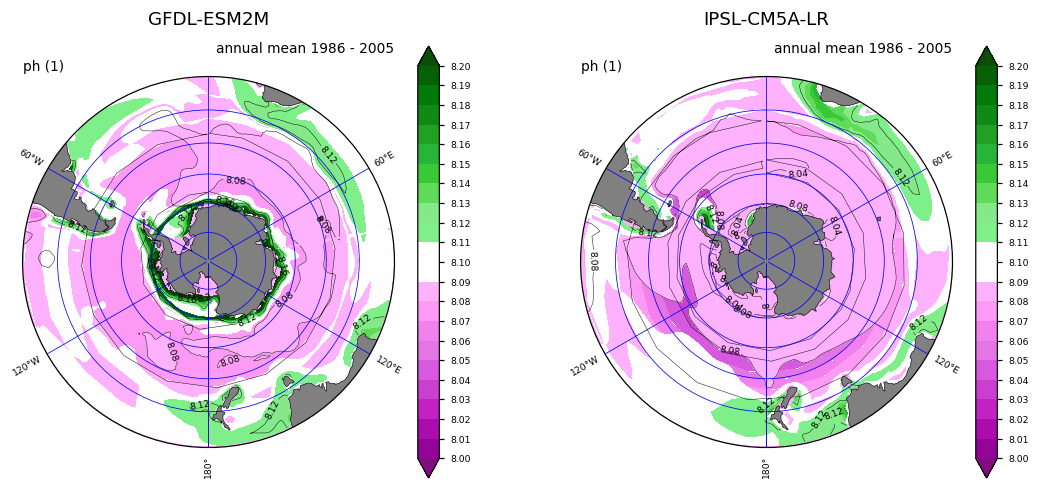

In [7]:
# Contour levels and colours of the original diagnostic
levels = np.arange(8.0, 8.2 + 0.01 / 2, 0.01)
cmap = ListedColormap(np.array([
    [132, 12, 127], [147, 5, 153], [172, 12, 173],
    [195, 33, 196], [203, 63, 209], [215, 89, 225],
    [229, 117, 230], [243, 129, 238], [253, 155, 247],
    [255, 178, 254], [255, 255, 255], [255, 255, 255],
    [126, 240, 138], [134, 234, 138], [95, 219, 89],
    [57, 201, 54], [39, 182, 57], [33, 161, 36],
    [16, 139, 22], [0, 123, 10], [6, 96, 6],
    [12, 77, 9.0]]) / 256.0)
norm = BoundaryNorm(levels, ncolors=cmap.N, extend="both")

# These are the recipe's levels, chosen for the models of the paper.
# A model whose values sit entirely inside one colour band comes out a
# single flat colour (correctly, but uninformatively).  Set AUTOSCALE
# to True to spread the levels over the actual data instead; the
# recipe palette is tied to its own levels, so a perceptual colormap
# is used in that case.
AUTOSCALE = False

# A few outlier cells (often unmasked land or marginal-sea points)
# draw tight contour rings whose colour bands are sub-pixel, which
# looks like a labelled line floating on flat fill.  Set this to e.g.
# 0.1 to mask the most extreme 0.1% at each end before plotting.
CLIP_PERCENTILE = 0.0

# circular boundary for the polar stereographic axes
theta = np.linspace(0, 2 * np.pi, 100)
circle = mpath.Path(
    np.vstack([np.sin(theta), np.cos(theta)]).T * 0.5 + [0.5, 0.5])

cubes = ph_cubes
fig = plt.figure(figsize=(6 * len(cubes), 6))

for iplot, (name, cube) in enumerate(cubes.items()):
    cube = surface_field(cube)
    lat = coord_1d_or_2d(cube, "latitude")
    lon = coord_1d_or_2d(cube, "longitude")
    if lat.ndim == 1:
        lon2d, lat2d = np.meshgrid(lon, lat)
    else:
        lat2d, lon2d = lat, lon

    data = np.ma.masked_invalid(cube.data) * 1.0
    # The cubes are global but the map shows the Southern Ocean only,
    # so drop everything north of the plot limit.  Otherwise the
    # statistics below describe the whole ocean, and contours of
    # northern-hemisphere features (the Baltic, the Great Lakes, the
    # Kara Sea) leak labels onto the plot.
    data = np.ma.masked_where(lat2d > -30.0, data)
    # Report percentiles as well as min/max.  If min/max sit far
    # outside the 1-99% range the field has outlier cells: those show
    # up as tight contour "bullseyes" whose colour bands are too small
    # to see, i.e. a labelled line apparently floating on flat fill.
    p1, p50, p99 = np.percentile(data.compressed(), [1, 50, 99])
    print(f"{name}: ph min {data.min():.4g}, max {data.max():.4g} | "
          f"1% {p1:.4g}, median {p50:.4g}, 99% {p99:.4g} | "
          f"levels {levels[0]:g}-{levels[-1]:g} | "
          f"{(data < levels[0]).mean():.1%} below, "
          f"{(data > levels[-1]).mean():.1%} above scale")

    if CLIP_PERCENTILE > 0:
        lo, hi = np.percentile(data.compressed(),
                               [CLIP_PERCENTILE, 100 - CLIP_PERCENTILE])
        data = np.ma.masked_outside(data, lo, hi)
        print(f"  clipped to {lo:.4g} - {hi:.4g}, "
              f"{data.mask.sum()} cells masked")

    # levels per model, so one model with an extreme range cannot
    # flatten the others
    if AUTOSCALE:
        lo, hi = np.percentile(data.compressed(), [2, 98])
        # MaxNLocator gives round numbers, so the colourbar and the
        # contour labels stay readable
        plot_levels = MaxNLocator(nbins=20).tick_values(lo, hi)
        plot_cmap, plot_norm = plt.get_cmap("viridis"), None
    else:
        plot_levels, plot_cmap, plot_norm = levels, cmap, norm

    ax = fig.add_subplot(1, len(cubes), iplot + 1,
                         projection=ccrs.SouthPolarStereo())
    ax.set_extent([-180, 180, -90, -30.0], ccrs.PlateCarree())
    ax.set_boundary(circle, transform=ax.transAxes)

    filled = ax.contourf(lon2d, lat2d, data, levels=plot_levels,
                         cmap=plot_cmap, norm=plot_norm, extend="both",
                         transform=ccrs.PlateCarree())
    # A line at every level is unreadable where the field is steep (all
    # 4 levels can be crossed within one or two grid cells,
    # which is what produces a solid black ring around Antarctica), so
    # draw and label every 4th level only.
    line_levels = plot_levels[::4]
    lines = ax.contour(lon2d, lat2d, data, levels=line_levels,
                       colors="black", linewidths=0.3,
                       transform=ccrs.PlateCarree())
    ax.clabel(lines, line_levels, fontsize=6, fmt="%.4g")
    ax.add_feature(cfeature.LAND, facecolor="grey", zorder=2)
    ax.coastlines(linewidth=0.4, zorder=3)
    gl = ax.gridlines(color="blue", linewidth=0.5,
                      draw_labels=True, x_inline=False, y_inline=False)
    gl.top_labels = gl.right_labels = False
    gl.xlabel_style = gl.ylabel_style = {"size": 6}

    # title on top, then the right and left strings below it, so that
    # they never overlap (the NCL layout)
    ax.set_title(name, fontsize=12, pad=34)
    ax.text(1.0, 1.065, "annual mean 1986 - 2005", ha="right",
            transform=ax.transAxes, fontsize=9)
    ax.text(0.0, 1.015, "ph (1)", ha="left",
            transform=ax.transAxes, fontsize=9)

    cbar = fig.colorbar(filled, ax=ax, orientation="vertical",
                        shrink=0.85, ticks=plot_levels[::2]
                        if AUTOSCALE else plot_levels)
    cbar.ax.tick_params(labelsize=6)

plt.show()

**Figure 8: Surface pH:** Annual mean surface pH over the Southern Ocean.